# Importing libraries

In [1]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import OneClassSVM
from sklearn.ensemble import IsolationForest
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import shap
import seaborn as sns


import math

from sklearn.utils import resample
from sklearn.metrics import recall_score, precision_score, fbeta_score
from sklearn.svm import OneClassSVM
from sklearn.ensemble import IsolationForest

C:\Users\ismai\anaconda3\envs\project_clean\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
data_csv = pd.read_csv(r"C:\Users\ismai\Downloads\archive (16)\equipment_anomaly_data.csv")

C:\Users\ismai\AppData\Local\Temp\ipykernel_26248\2531965560.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\ismai\AppData\Local\Temp\ipykernel_26248\2531965560.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\ismai\AppData\Local\Temp\ipykernel_26248\2531965560.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\ismai\AppData\Local\Temp\ipykernel_26248\2531965560.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `h

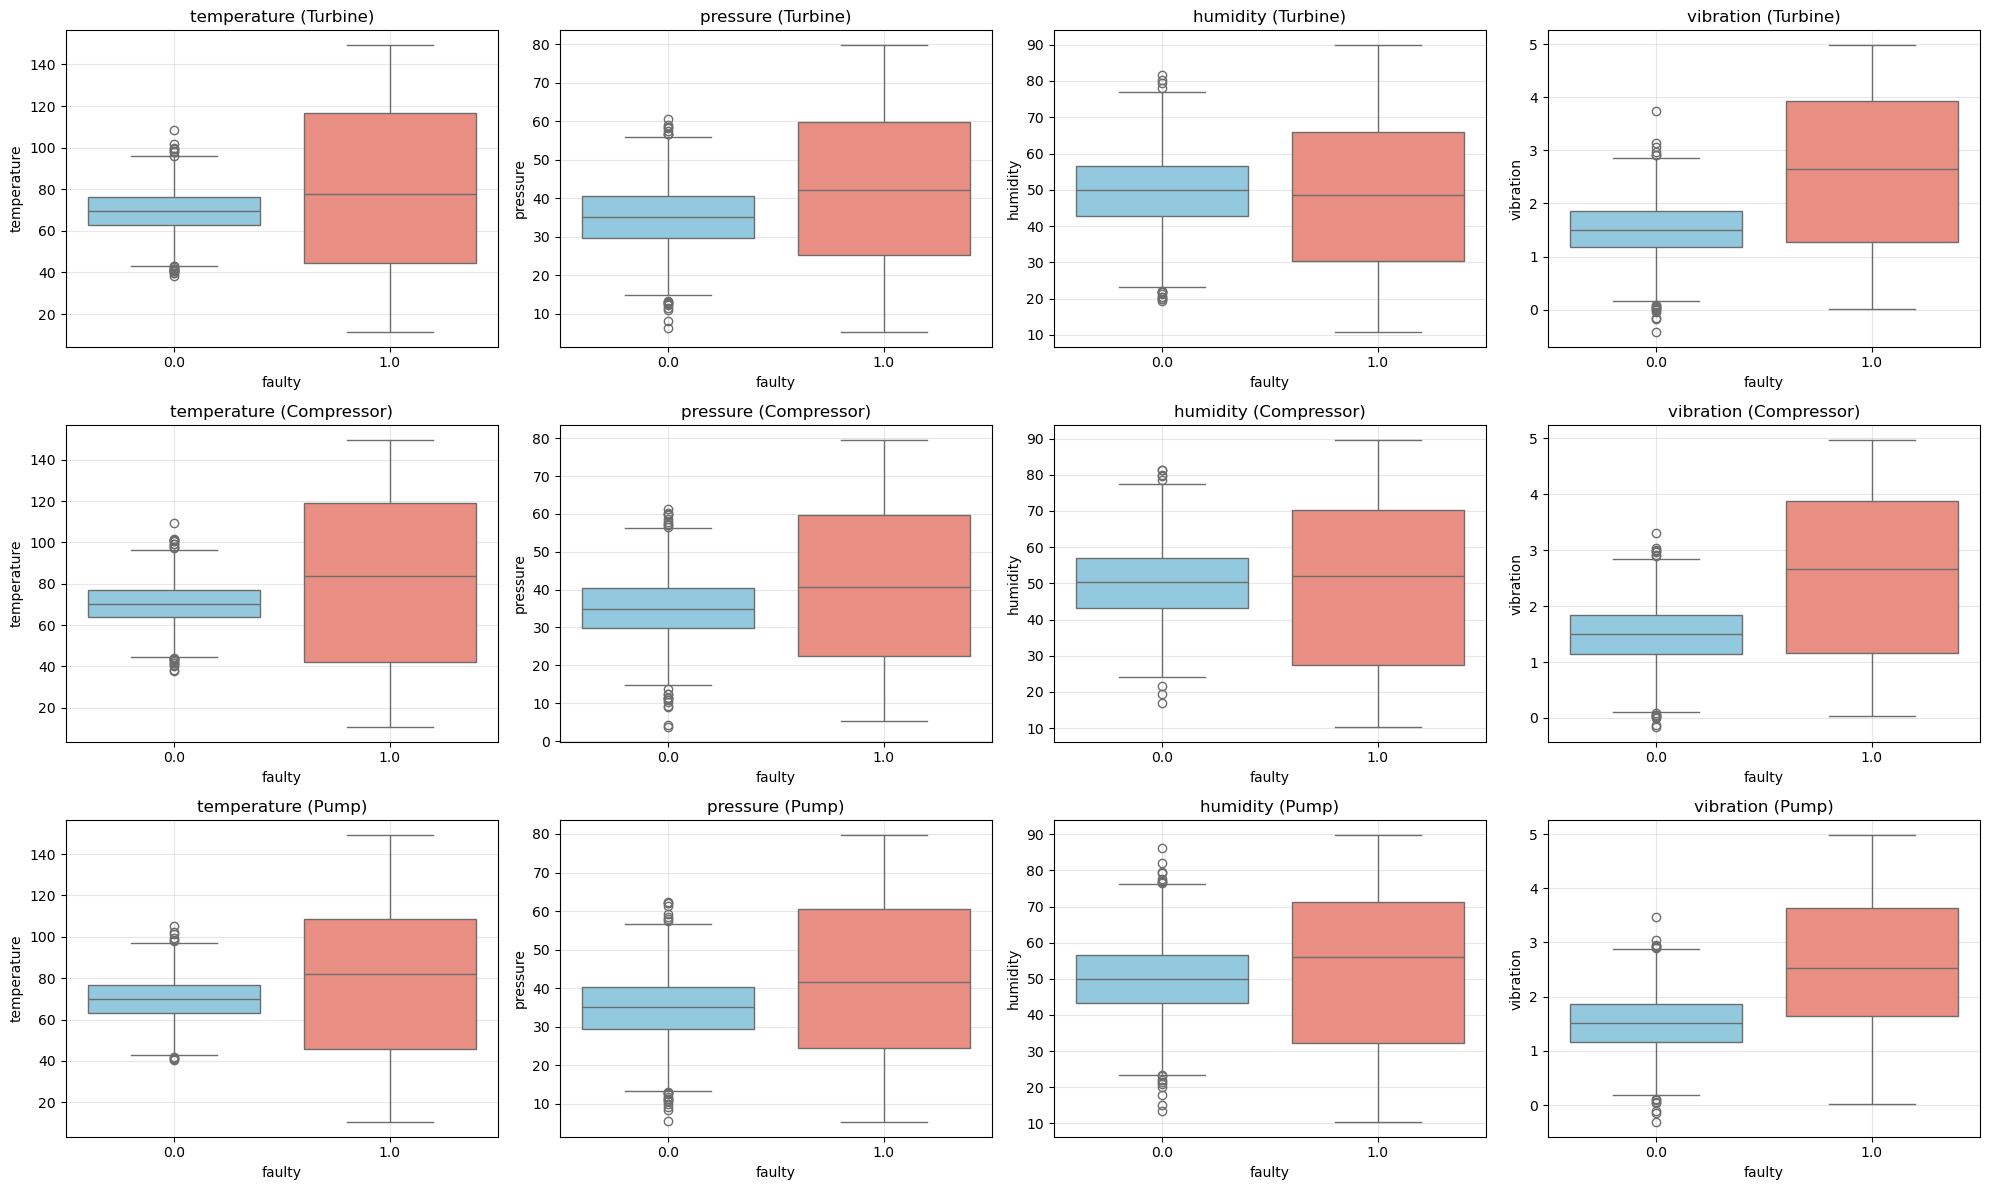

In [3]:


target_col = 'faulty'
equipment_col = 'equipment'

variables = ['temperature', 'pressure', 'humidity', 'vibration']
equipment_types = data_csv[equipment_col].unique()

# Create grid: rows = equipment types, cols = variables
fig, axes = plt.subplots(
    len(equipment_types), 
    len(variables),
    figsize=(5*len(variables), 4*len(equipment_types))
)

# If only one equipment type exists, fix axis shape
if len(equipment_types) == 1:
    axes = axes.reshape(1, -1)

for row, eq in enumerate(equipment_types):
    
    subset = data_csv[data_csv[equipment_col] == eq]
    
    for col, var in enumerate(variables):
        
        sns.boxplot(
            x=target_col,
            y=var,
            data=subset,
            palette=['skyblue', 'salmon'],
            ax=axes[row, col]
        )
        
        axes[row, col].set_title(f"{var} ({eq})")
        axes[row, col].grid(alpha=0.3)

plt.tight_layout()
plt.show()

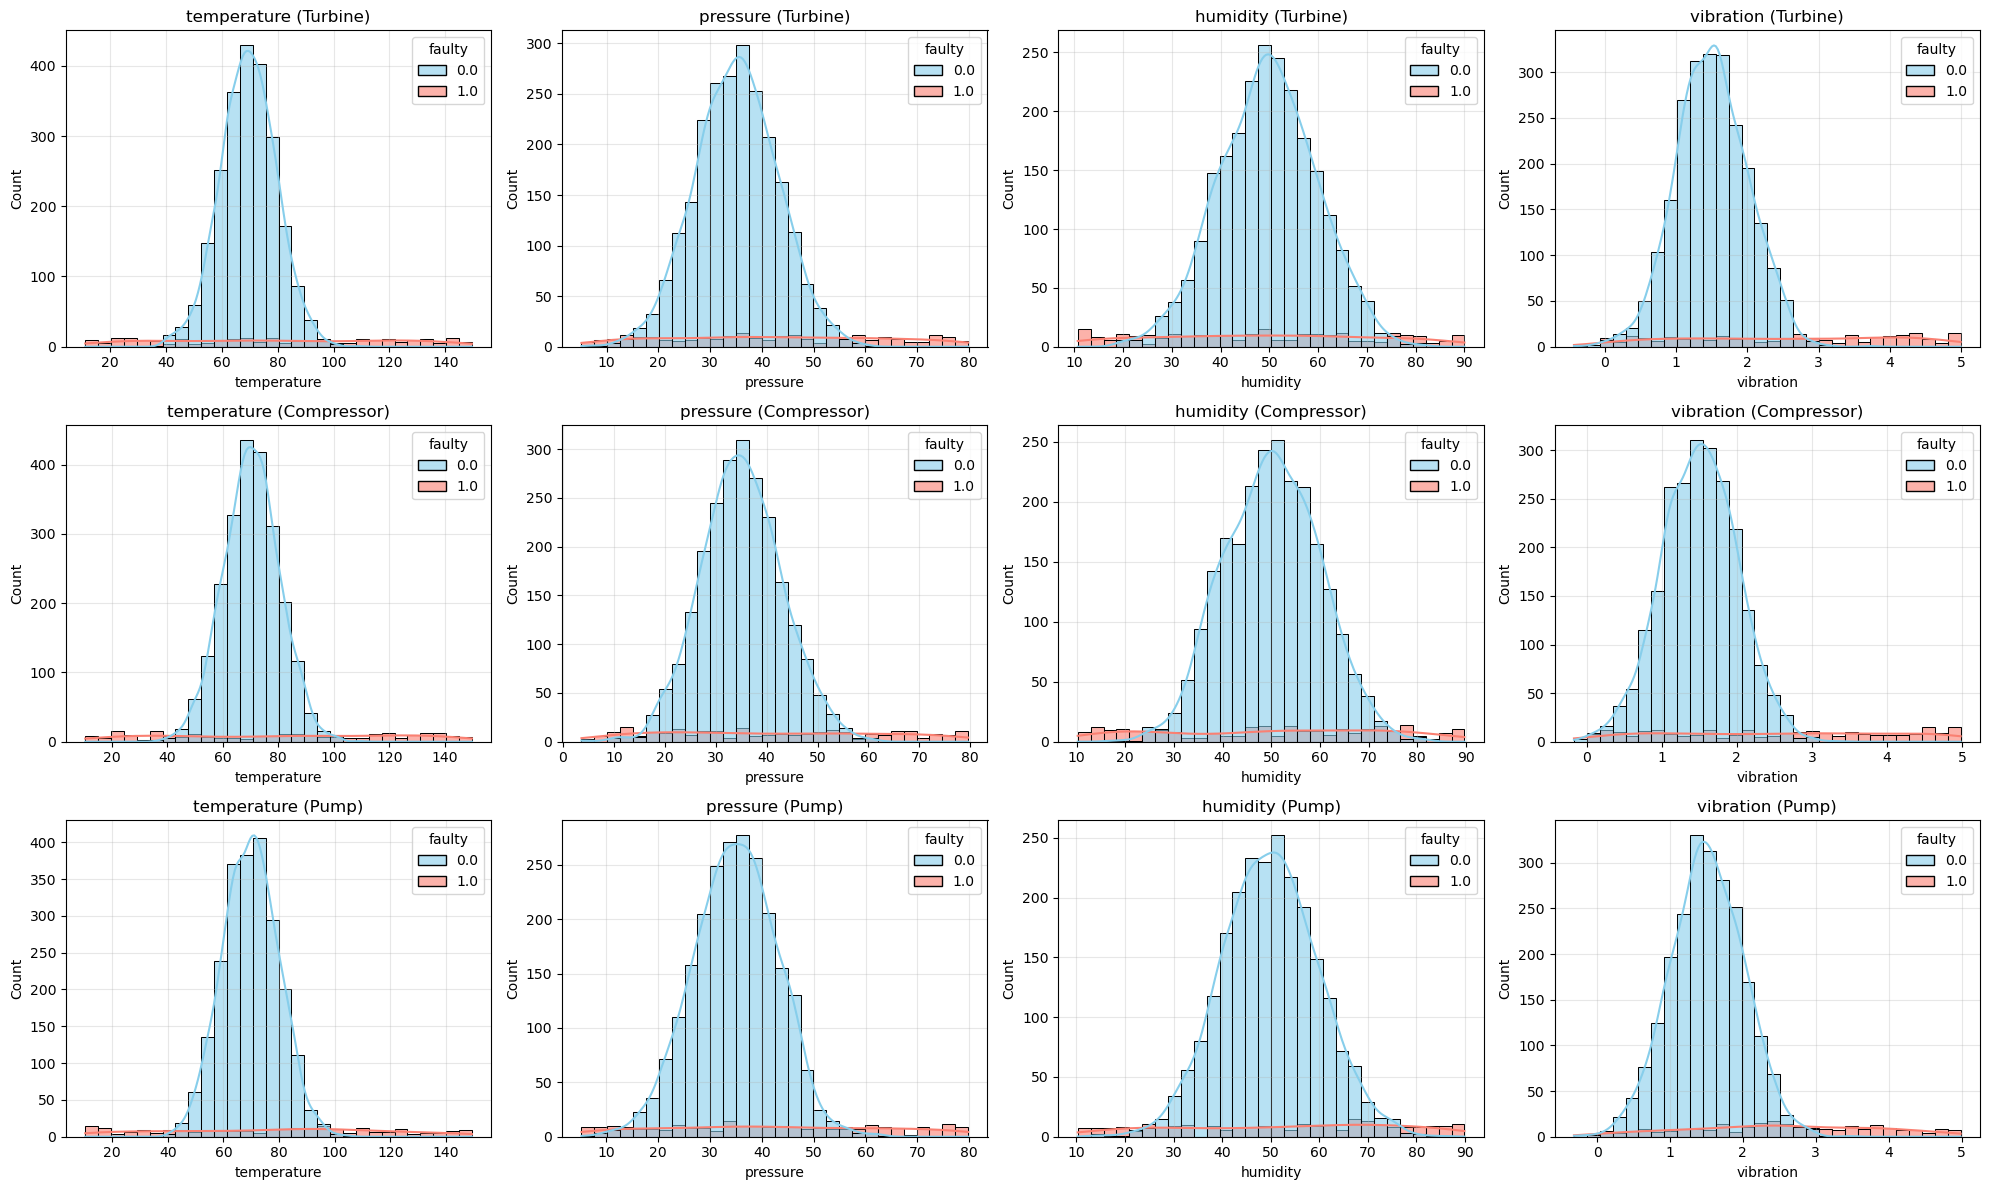

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

target_col = 'faulty'
equipment_col = 'equipment'

variables = ['temperature', 'pressure', 'humidity', 'vibration']
equipment_types = data_csv[equipment_col].unique()

fig, axes = plt.subplots(
    len(equipment_types),
    len(variables),
    figsize=(5*len(variables), 4*len(equipment_types))
)

# Fix shape if only one equipment
if len(equipment_types) == 1:
    axes = axes.reshape(1, -1)

for row, eq in enumerate(equipment_types):
    
    subset = data_csv[data_csv[equipment_col] == eq]
    
    for col, var in enumerate(variables):
        
        sns.histplot(
            data=subset,
            x=var,
            hue=target_col,
            bins=30,
            kde=True,
            palette=['skyblue', 'salmon'],
            alpha=0.6,
            ax=axes[row, col]
        )
        
        axes[row, col].set_title(f"{var} ({eq})")
        axes[row, col].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [5]:
no_faulty_data = data_csv[data_csv['faulty'] == 0.0]
no_faulty_equipment = data_csv[data_csv['faulty'] == 0.0]['equipment']
#.drop('equipment',axis = 1)
no_faulty_train, no_faulty_test = train_test_split(no_faulty_data, test_size=0.2, stratify = no_faulty_equipment, shuffle=True, random_state=42)

no_faulty_train = no_faulty_train.drop(['faulty','location','equipment'],axis = 1)

faulty_data = data_csv[data_csv['faulty'] == 1.0]
test = pd.concat([no_faulty_test, faulty_data], ignore_index=True)
test = test.sample(frac=1, random_state=42).reset_index(drop=True)
X_test = test.drop(columns=['faulty']) 
y_test = test['faulty']               
X_test_copy = test.copy()

X_test = X_test.drop(['location','equipment'],axis = 1)


In [6]:
scaler = StandardScaler()

In [7]:
X_train_scaled = scaler.fit_transform(no_faulty_train)
X_test_scaled = scaler.transform(X_test)

In [8]:
ocsvm = OneClassSVM(
    kernel='rbf', 
    gamma='auto', 
    nu=0.05
)

ocsvm.fit(X_train_scaled)


y_pred_ocsvm = ocsvm.predict(X_test_scaled)
y_pred_ocsvm = [0 if i == 1 else 1 for i in y_pred_ocsvm]

              precision    recall  f1-score   support

      Normal       0.97      0.94      0.95      1381
      Faulty       0.89      0.95      0.92       767

    accuracy                           0.94      2148
   macro avg       0.93      0.94      0.94      2148
weighted avg       0.94      0.94      0.94      2148

[[1292   89]
 [  36  731]]


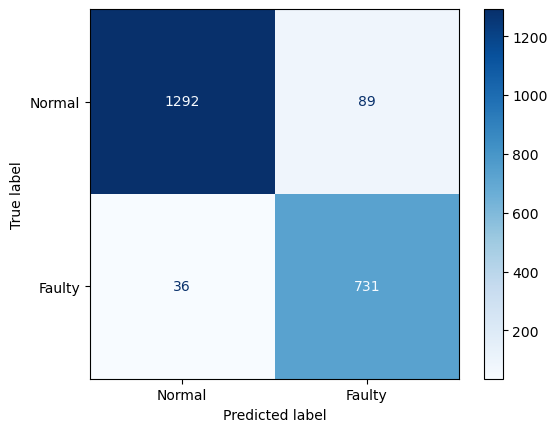

In [9]:
X_test_copy['predictions_osvm'] = y_pred_ocsvm

print(classification_report(y_test, y_pred_ocsvm, target_names=['Normal','Faulty']))

cm_ocsvm = confusion_matrix(y_test, y_pred_ocsvm)
print(cm_ocsvm)

disp_ocsvm = ConfusionMatrixDisplay(cm_ocsvm, display_labels=['Normal','Faulty'])
disp_ocsvm.plot(cmap=plt.cm.Blues)
plt.show()

In [10]:
isoforest = IsolationForest(
    n_estimators=100,
    contamination=0.05,
    random_state=42
)

isoforest.fit(X_train_scaled)


y_pred_isoforest = isoforest.predict(X_test_scaled)
y_pred_isoforest = [0 if i == 1 else 1 for i in y_pred_isoforest]

              precision    recall  f1-score   support

      Normal       0.96      0.95      0.95      1381
      Faulty       0.91      0.93      0.92       767

    accuracy                           0.94      2148
   macro avg       0.93      0.94      0.94      2148
weighted avg       0.94      0.94      0.94      2148

[[1309   72]
 [  53  714]]


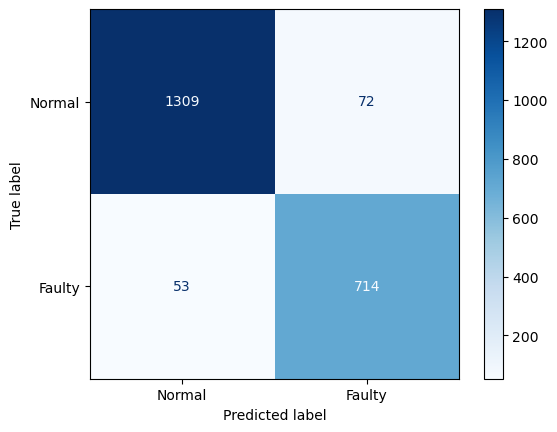

In [11]:
X_test_copy['iso_forest_predictions'] = y_pred_isoforest

print(classification_report(y_test, y_pred_isoforest, target_names=['Normal', 'Faulty']))

cm_isoforest = confusion_matrix(y_test, y_pred_isoforest)
print(cm_isoforest)

disp_isoforest = ConfusionMatrixDisplay(confusion_matrix=cm_isoforest, display_labels=['Normal', 'Faulty'])
disp_isoforest.plot(cmap=plt.cm.Blues)
plt.show()


In [12]:
scores = ocsvm.decision_function(X_test_scaled)
anomaly_scores = -scores

scores_iso = isoforest.decision_function(X_test_scaled)
anomaly_scores_iso = -scores_iso

X_test_copy['ocsvm_anomaly_scores'] = anomaly_scores
X_test_copy['iso_fores_anomaly_scores'] = anomaly_scores_iso

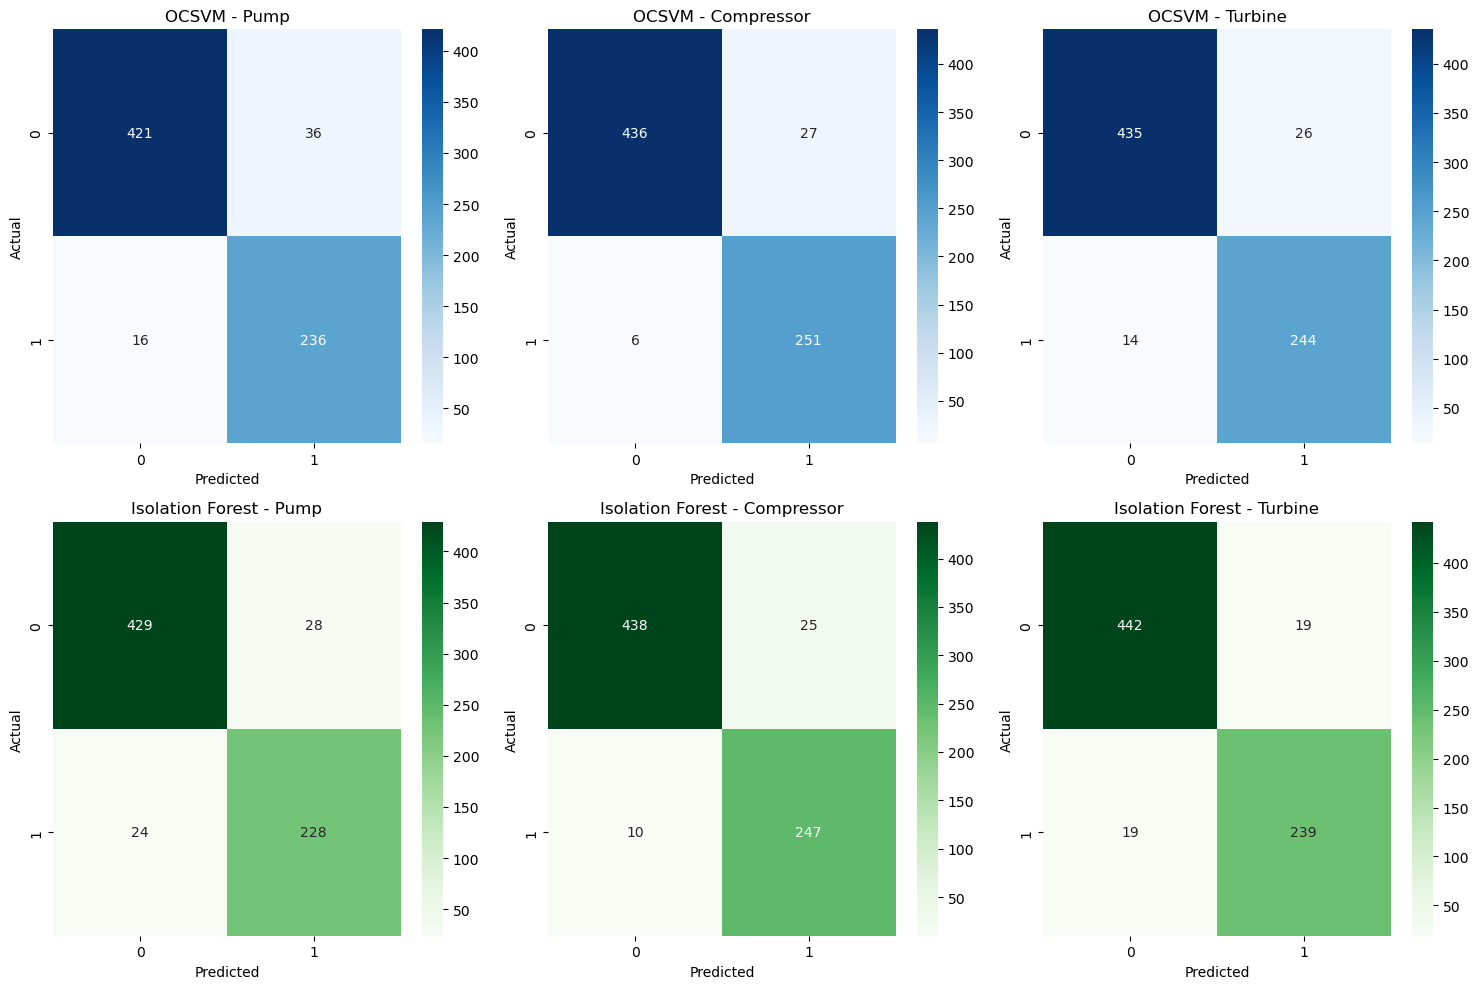

In [45]:
equipment_types = X_test_copy['equipment'].unique()

fig, axes = plt.subplots(
    2, 
    len(equipment_types),
    figsize=(5 * len(equipment_types), 10)  
)

for col, eq in enumerate(equipment_types):
    
    subset = X_test_copy[X_test_copy['equipment'] == eq]
    
    y_true = subset['faulty']
    y_pred_ocsvm = subset['predictions_osvm']
    y_pred_iso = subset['iso_forest_predictions']
    
    cm_ocsvm = confusion_matrix(y_true, y_pred_ocsvm)
    cm_iso = confusion_matrix(y_true, y_pred_iso)
    
    sns.heatmap(cm_ocsvm, annot=True, fmt='d',
                cmap='Blues',
                ax=axes[0, col])
    axes[0, col].set_title(f"OCSVM - {eq}")
    axes[0, col].set_xlabel("Predicted")
    axes[0, col].set_ylabel("Actual")
    
    # Row 1 → Isolation Forest
    sns.heatmap(cm_iso, annot=True, fmt='d',
                cmap='Greens',
                ax=axes[1, col])
    axes[1, col].set_title(f"Isolation Forest - {eq}")
    axes[1, col].set_xlabel("Predicted")
    axes[1, col].set_ylabel("Actual")

plt.tight_layout()
plt.savefig('Grid_anomaly_fault_detection_plot')
plt.show()

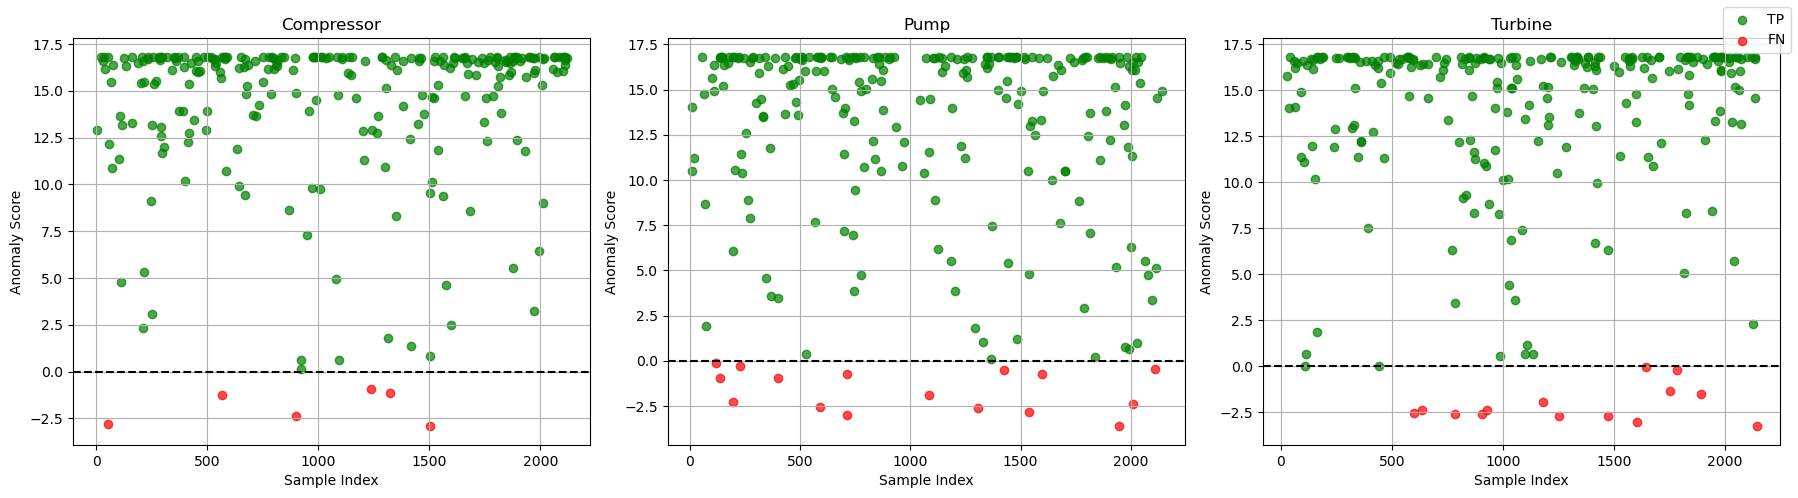

In [46]:

# Ensure clean indexing
plot_df = X_test_copy.reset_index(drop=True)

# Define TP / FN labels
plot_df['label'] = np.where(
    (plot_df['faulty']==1) & (plot_df['predictions_osvm']==1), 'TP',
    np.where(
        (plot_df['faulty']==1) & (plot_df['predictions_osvm']==0), 'FN',
        'Other'
    )
)

# Unique equipments
equipments = sorted(plot_df['equipment'].unique())

# Create 3 subplots (since you have 3 machines)
fig, axes = plt.subplots(1, 3, figsize=(18,5))

colors = {
    'TP': 'green',
    'FN': 'red'
}

for ax, eq in zip(axes, equipments):

    eq_df = plot_df[plot_df['equipment'] == eq]

    # Plot TP + FN only
    for label in ['TP','FN']:

        sub = eq_df[eq_df['label'] == label]

        ax.scatter(
            sub.index,
            sub['ocsvm_anomaly_scores'],
            color=colors[label],
            label=label,
            alpha=0.7
        )

    ax.axhline(0, linestyle='--', color='black')
    ax.set_title(f"{eq}")
    ax.set_xlabel("Sample Index")
    ax.set_ylabel("Anomaly Score")
    ax.grid(True)

# Add legend once
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper right')

plt.tight_layout()
plt.savefig('Anomaly_scores_ocsvm')
plt.show()

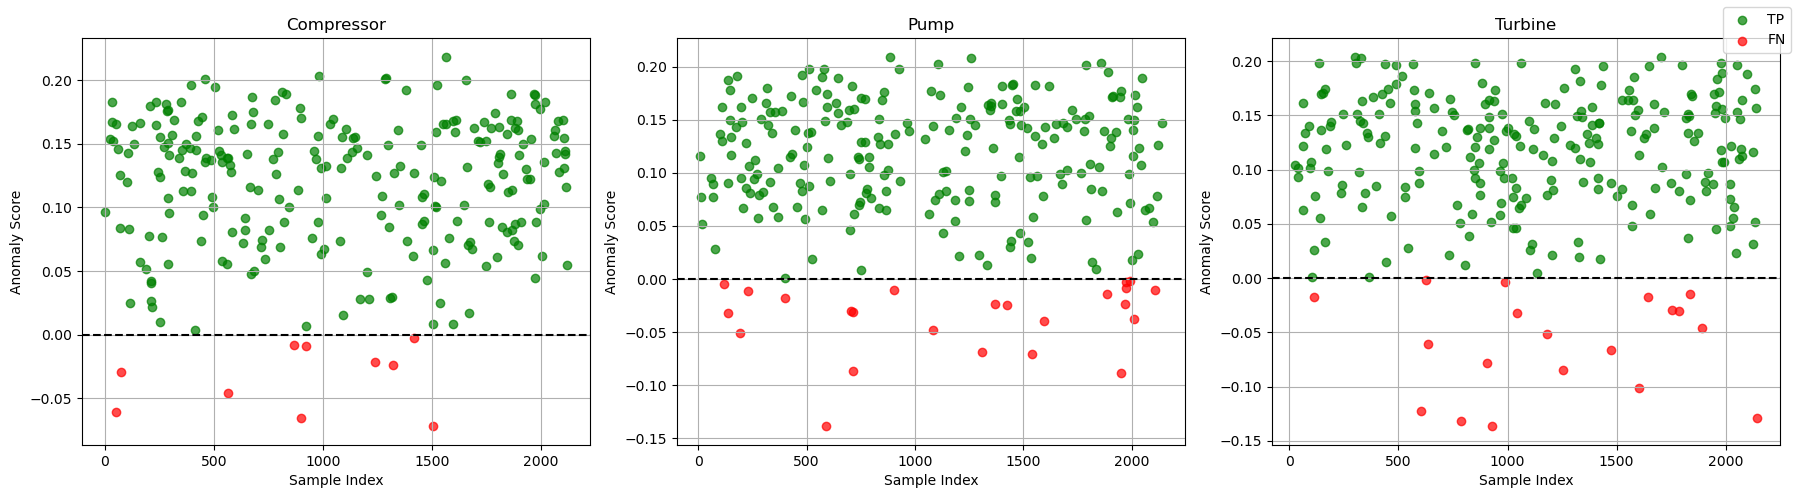

In [47]:

# Ensure clean indexing
plot_df = X_test_copy.reset_index(drop=True)

# Define TP / FN labels
plot_df['label'] = np.where(
    (plot_df['faulty']==1) & (plot_df['iso_forest_predictions']==1), 'TP',
    np.where(
        (plot_df['faulty']==1) & (plot_df['iso_forest_predictions']==0), 'FN',
        'Other'
    )
)

# Unique equipments
equipments = sorted(plot_df['equipment'].unique())

# Create 3 subplots (since you have 3 machines)
fig, axes = plt.subplots(1, 3, figsize=(18,5))

colors = {
    'TP': 'green',
    'FN': 'red'
}

for ax, eq in zip(axes, equipments):

    eq_df = plot_df[plot_df['equipment'] == eq]

    # Plot TP + FN only
    for label in ['TP','FN']:

        sub = eq_df[eq_df['label'] == label]

        ax.scatter(
            sub.index,
            sub['iso_fores_anomaly_scores'],
            color=colors[label],
            label=label,
            alpha=0.7
        )

    ax.axhline(0, linestyle='--', color='black')
    ax.set_title(f"{eq}")
    ax.set_xlabel("Sample Index")
    ax.set_ylabel("Anomaly Score")
    ax.grid(True)

# Add legend once
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper right')

plt.tight_layout()
plt.savefig('Anomaly_scores_ISOFOREST')
plt.show()

In [15]:
from sklearn.metrics import precision_score, recall_score, fbeta_score
import pandas as pd

metrics_results = []

for eq in equipment_types:
    
    subset = X_test_copy[X_test_copy['equipment'] == eq]
    
    y_true = subset['faulty']
    y_pred_ocsvm = subset['predictions_osvm']
    y_pred_iso = subset['iso_forest_predictions']
    
    # --- OCSVM Metrics ---
    precision_oc = precision_score(y_true, y_pred_ocsvm)
    recall_oc = recall_score(y_true, y_pred_ocsvm)
    f2_oc = fbeta_score(y_true, y_pred_ocsvm, beta=2)
    
    metrics_results.append({
        'Equipment': eq,
        'Model': 'OCSVM',
        'Precision': precision_oc,
        'Recall': recall_oc,
        'F2_score': f2_oc
    })
    
    # --- Isolation Forest Metrics ---
    precision_iso = precision_score(y_true, y_pred_iso)
    recall_iso = recall_score(y_true, y_pred_iso)
    f2_iso = fbeta_score(y_true, y_pred_iso, beta=2)
    
    metrics_results.append({
        'Equipment': eq,
        'Model': 'IsolationForest',
        'Precision': precision_iso,
        'Recall': recall_iso,
        'F2_score': f2_iso
    })

# Convert to DataFrame
metrics_df = pd.DataFrame(metrics_results)

print("\nModel Performance Per Equipment:\n")
print(metrics_df)


Model Performance Per Equipment:

    Equipment            Model  Precision    Recall  F2_score
0        Pump            OCSVM   0.867647  0.936508  0.921875
1        Pump  IsolationForest   0.890625  0.904762  0.901899
2  Compressor            OCSVM   0.902878  0.976654  0.960949
3  Compressor  IsolationForest   0.908088  0.961089  0.950000
4     Turbine            OCSVM   0.903704  0.945736  0.937020
5     Turbine  IsolationForest   0.926357  0.926357  0.926357


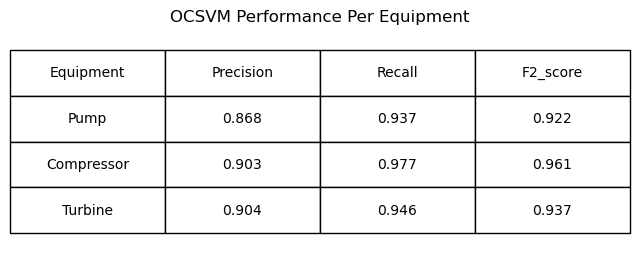

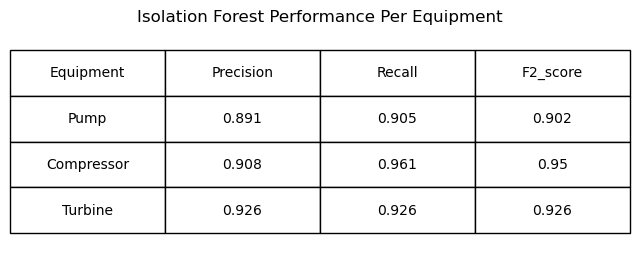

In [53]:
import matplotlib.pyplot as plt

# Split tables
ocsvm_table = metrics_df[metrics_df['Model'] == 'OCSVM'].drop(columns='Model')
iso_table = metrics_df[metrics_df['Model'] == 'IsolationForest'].drop(columns='Model')

# ---------- OCSVM ----------
fig, ax = plt.subplots(figsize=(8, 2.8))
ax.axis('off')

ax.set_title("OCSVM Performance Per Equipment", pad=5)

table1 = ax.table(
    cellText=ocsvm_table.values,
    colLabels=ocsvm_table.columns,
    cellLoc='center',
    bbox=[0, 0.05, 1, 0.85]   # moves table upward
)

table1.auto_set_font_size(False)
table1.set_fontsize(10)
table1.scale(1, 1.3)

plt.savefig("ocsvm_performance_table.png", bbox_inches='tight')
plt.show()

# ---------- ISO FOREST ----------
fig, ax = plt.subplots(figsize=(8, 2.8))
ax.axis('off')

ax.set_title("Isolation Forest Performance Per Equipment", pad=5)

table2 = ax.table(
    cellText=iso_table.values,
    colLabels=iso_table.columns,
    cellLoc='center',
    bbox=[0, 0.05, 1, 0.85]
)

table2.auto_set_font_size(False)
table2.set_fontsize(10)
table2.scale(1, 1.3)

plt.savefig("isolation_forest_performance_table.png", bbox_inches='tight')
plt.show()


===== BOOTSTRAP RESULTS =====

OCSVM:
Recall: 0.953089960886571 ± 0.0037741250007144326
Precision: 0.8875925194523507 ± 0.006122697978653118
F2: 0.9392138409327313 ± 0.002469015386264325

Isolation Forest:
Recall: 0.929295958279009 ± 0.005122565199823535
Precision: 0.9068431809994647 ± 0.006744648642172305
F2: 0.9247016936084113 ± 0.004036226669031902


C:\Users\ismai\AppData\Local\Temp\ipykernel_26248\628070959.py:89: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([metrics_oc[:,0], metrics_if[:,0]],
C:\Users\ismai\AppData\Local\Temp\ipykernel_26248\628070959.py:94: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([metrics_oc[:,1], metrics_if[:,1]],
C:\Users\ismai\AppData\Local\Temp\ipykernel_26248\628070959.py:99: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([metrics_oc[:,2], metrics_if[:,2]],


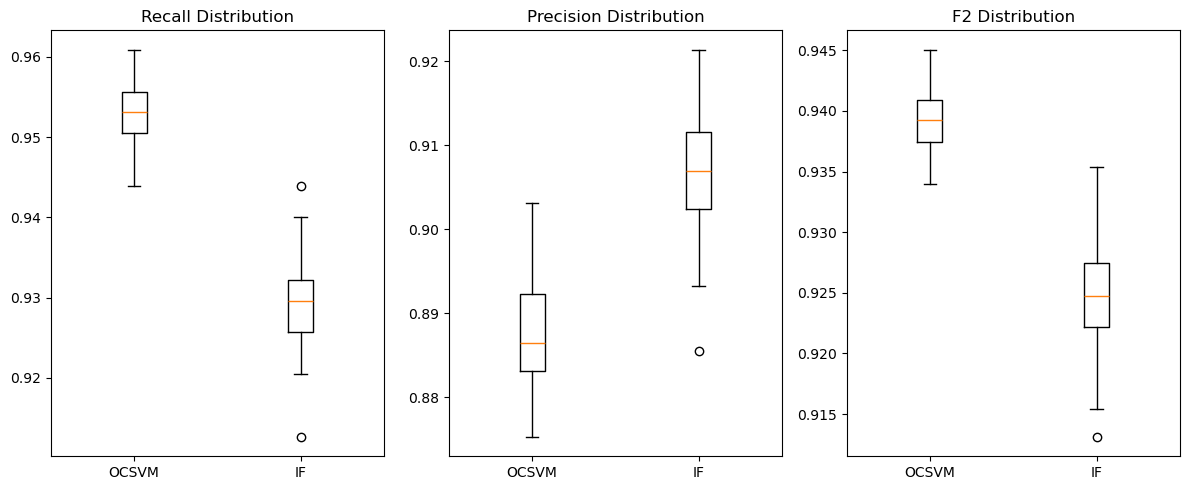

In [48]:
n_runs = 100

X_test = X_test_scaled
y_test = X_test_copy['faulty'].values

# Use only normal training data for anomaly detection training
normal_train = X_train_scaled

# Storage
metrics_oc = []
metrics_if = []

# ---------------------------
# BOOTSTRAP LOOP
# ---------------------------
for i in range(n_runs):

    # Bootstrap training data
    boot_train = resample(
        normal_train,
        replace=True,
        n_samples=len(normal_train),
        random_state=i
    )

    # -------------------
    # Train OCSVM
    # -------------------
    oc = OneClassSVM(
        kernel='rbf',
        gamma='auto',
        nu=0.05
    )

    oc.fit(boot_train)

    pred_oc = (oc.predict(X_test) == -1).astype(int)

    metrics_oc.append([
        recall_score(y_test, pred_oc),
        precision_score(y_test, pred_oc),
        fbeta_score(y_test, pred_oc, beta=2)
    ])

    # -------------------
    # Train Isolation Forest
    # -------------------
    iso = IsolationForest(
        n_estimators=100,
        contamination=0.05,
        random_state=42
    )

    iso.fit(boot_train)

    pred_if = (iso.predict(X_test) == -1).astype(int)

    metrics_if.append([
        recall_score(y_test, pred_if),
        precision_score(y_test, pred_if),
        fbeta_score(y_test, pred_if, beta=2)
    ])

# Convert to arrays
metrics_oc = np.array(metrics_oc)
metrics_if = np.array(metrics_if)

# ---------------------------
# RESULTS
# ---------------------------
print("\n===== BOOTSTRAP RESULTS =====")

print("\nOCSVM:")
print("Recall:", np.mean(metrics_oc[:,0]), "±", np.std(metrics_oc[:,0]))
print("Precision:", np.mean(metrics_oc[:,1]), "±", np.std(metrics_oc[:,1]))
print("F2:", np.mean(metrics_oc[:,2]), "±", np.std(metrics_oc[:,2]))

print("\nIsolation Forest:")
print("Recall:", np.mean(metrics_if[:,0]), "±", np.std(metrics_if[:,0]))
print("Precision:", np.mean(metrics_if[:,1]), "±", np.std(metrics_if[:,1]))
print("F2:", np.mean(metrics_if[:,2]), "±", np.std(metrics_if[:,2]))

# ---------------------------
# VISUALIZATION
# ---------------------------
plt.figure(figsize=(12,5))

plt.subplot(1,3,1)
plt.boxplot([metrics_oc[:,0], metrics_if[:,0]],
            labels=['OCSVM','IF'])
plt.title("Recall Distribution")

plt.subplot(1,3,2)
plt.boxplot([metrics_oc[:,1], metrics_if[:,1]],
            labels=['OCSVM','IF'])
plt.title("Precision Distribution")

plt.subplot(1,3,3)
plt.boxplot([metrics_oc[:,2], metrics_if[:,2]],
            labels=['OCSVM','IF'])
plt.title("F2 Distribution")

plt.tight_layout()
plt.savefig('Bootstrapping_100_runs_metrics')
plt.show()

In [17]:
import time

start = time.time()
isoforest.predict(X_test_scaled)
print("Isolation Forest inference time:", time.time() - start)

start = time.time()
ocsvm.predict(X_test_scaled)
print("OC-SVM inference time:", time.time() - start)


Isolation Forest inference time: 0.009719133377075195
OC-SVM inference time: 0.02727651596069336


In [18]:
import pickle, os

pickle.dump(isoforest, open("iso.pkl","wb"))
pickle.dump(ocsvm, open("ocsvm.pkl","wb"))

print("IF size (KB):", os.path.getsize("iso.pkl")/1024)
print("OC-SVM size (KB):", os.path.getsize("ocsvm.pkl")/1024)


IF size (KB): 1107.5078125
OC-SVM size (KB): 13.9326171875


              Model  Training Time (s)  Model Size (KB)
0  Isolation Forest              0.009        1107.5078
1            OC-SVM              0.027          13.7812


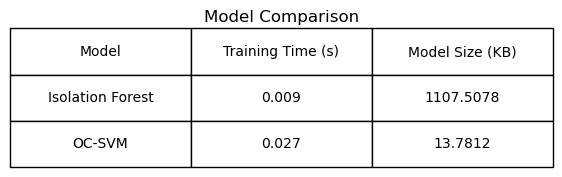

In [57]:
import time
import pickle
import os
import pandas as pd

# ---------- Inference time ----------
start = time.time()
isoforest.predict(X_test_scaled)
iso_time = time.time() - start

start = time.time()
ocsvm.predict(X_test_scaled)
ocsvm_time = time.time() - start

# ---------- Save models ----------
pickle.dump(isoforest, open("iso.pkl", "wb"))
pickle.dump(ocsvm, open("ocsvm.pkl", "wb"))

# ---------- Model sizes ----------
iso_size = os.path.getsize("iso.pkl") / 1024
ocsvm_size = os.path.getsize("ocsvm.pkl") / 1024

# ---------- Create table ----------
comparison_df = pd.DataFrame({
    'Model': ['Isolation Forest', 'OC-SVM'],
    'Training Time (s)': [iso_time, ocsvm_time],
    'Model Size (KB)': [iso_size, ocsvm_size]
})

# Round values
comparison_df[['Training Time (s)', 'Model Size (KB)']] = comparison_df[
    ['Training Time (s)', 'Model Size (KB)']
].round(4)

print(comparison_df)





fig, ax = plt.subplots(figsize=(7, 1.8))
ax.axis('off')

table = ax.table(
    cellText=comparison_df.values,
    colLabels=comparison_df.columns,
    cellLoc='center',
    bbox=[0, 0, 1, 1]
)

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 1.4)

plt.title("Model Comparison", pad=5)
plt.savefig("model_comparison_table.png", bbox_inches='tight')
plt.show()

In [19]:
X_test_noisy = X_test_scaled + np.random.normal(0, 0.01, X_test_scaled.shape)

pred_if = (isoforest.predict(X_test_noisy) == -1).astype(int)
pred_oc = (ocsvm.predict(X_test_noisy) == -1).astype(int)

print("IF noisy recall:",
      recall_score(y_test, pred_if, pos_label=1))

print("OC noisy recall:",
      recall_score(y_test, pred_oc, pos_label=1))


IF noisy recall: 0.9322033898305084
OC noisy recall: 0.9517601043024772


In [60]:
import numpy as np
import pandas as pd
from sklearn.metrics import recall_score

noise_levels = [0.01, 0.05, 0.10, 0.90]

noise_results = []

for noise in noise_levels:
    
    # Add Gaussian noise
    X_test_noisy = X_test_scaled + np.random.normal(
        0, noise, X_test_scaled.shape
    )
    
    # Predictions
    pred_if = (isoforest.predict(X_test_noisy) == -1).astype(int)
    pred_oc = (ocsvm.predict(X_test_noisy) == -1).astype(int)
    
    # Recall scores
    recall_if = recall_score(y_test, pred_if, pos_label=1)
    recall_oc = recall_score(y_test, pred_oc, pos_label=1)
    
    noise_results.append({
        'Noise Level (%)': int(noise * 100),
        'Isolation Forest Recall': round(recall_if, 4),
        'OC-SVM Recall': round(recall_oc, 4)
    })

# Create results table
noise_df = pd.DataFrame(noise_results)

print(noise_df)

from sklearn.metrics import precision_score, recall_score, f1_score

print("IF precision:", precision_score(y_test, pred_if))
print("IF recall:", recall_score(y_test, pred_if))

print("OC precision:", precision_score(y_test, pred_oc))
print("OC recall:", recall_score(y_test, pred_oc))

print("IF anomaly rate:", pred_if.mean())
print("OC anomaly rate:", pred_oc.mean())

   Noise Level (%)  Isolation Forest Recall  OC-SVM Recall
0                1                   0.9309         0.9518
1                5                   0.9296         0.9518
2               10                   0.9296         0.9492
3               90                   0.9309         0.9583
IF precision: 0.6580645161290323
IF recall: 0.9308996088657105
OC precision: 0.6627592425608656
OC recall: 0.9582790091264668
IF anomaly rate: 0.50512104283054
OC anomaly rate: 0.5162942271880819


In [62]:
import numpy as np
import pandas as pd
from sklearn.metrics import precision_score, recall_score, fbeta_score

noise_levels = [0.01, 0.05, 0.10, 0.90]

rows = []

for noise in noise_levels:
    
    # Add Gaussian noise
    X_test_noisy = X_test_scaled + np.random.normal(
        0, noise, X_test_scaled.shape
    )
    
    # Predictions
    pred_if = (isoforest.predict(X_test_noisy) == -1).astype(int)
    pred_oc = (ocsvm.predict(X_test_noisy) == -1).astype(int)
    
    # ----- OC-SVM row -----
    rows.append({
        'Model': 'OC-SVM',
        'Noise Level (%)': int(noise * 100),
        'Precision': round(precision_score(y_test, pred_oc), 4),
        'Recall': round(recall_score(y_test, pred_oc), 4),
        'F2 Score': round(fbeta_score(y_test, pred_oc, beta=2), 4),
        'Anomaly Rate': round(pred_oc.mean(), 4)
    })
    
    # ----- Isolation Forest row -----
    rows.append({
        'Model': 'Isolation Forest',
        'Noise Level (%)': int(noise * 100),
        'Precision': round(precision_score(y_test, pred_if), 4),
        'Recall': round(recall_score(y_test, pred_if), 4),
        'F2 Score': round(fbeta_score(y_test, pred_if, beta=2), 4),
        'Anomaly Rate': round(pred_if.mean(), 4)
    })

# Create dataframe
noise_df = pd.DataFrame(rows)

# Set hierarchical index
noise_df = noise_df.set_index(['Model', 'Noise Level (%)'])

print(noise_df)

                                  Precision  Recall  F2 Score  Anomaly Rate
Model            Noise Level (%)                                           
OC-SVM           1                   0.8913  0.9518    0.9390        0.3813
Isolation Forest 1                   0.9084  0.9309    0.9263        0.3659
OC-SVM           5                   0.8911  0.9492    0.9369        0.3804
Isolation Forest 5                   0.9040  0.9335    0.9275        0.3687
OC-SVM           10                  0.8879  0.9505    0.9373        0.3822
Isolation Forest 10                  0.9049  0.9309    0.9256        0.3673
OC-SVM           90                  0.6540  0.9661    0.8819        0.5275
Isolation Forest 90                  0.6651  0.9374    0.8665        0.5033


In [64]:
import numpy as np
import pandas as pd
from sklearn.metrics import precision_score, recall_score, fbeta_score

noise_levels = [0.01, 0.05, 0.10, 0.90]

rows = []

for model_name, model in [('OCSVM', ocsvm), ('IF', isoforest)]:
    
    for i, noise in enumerate(noise_levels):
        X_test_noisy = X_test_scaled + np.random.normal(
            0, noise, X_test_scaled.shape
        )
        
        pred = (model.predict(X_test_noisy) == -1).astype(int)
        
        rows.append({
            'Model': model_name if i == 0 else '',
            'Noise Level': f"{int(noise*100)}%",
            'Precision': round(precision_score(y_test, pred), 4),
            'Recall': round(recall_score(y_test, pred), 4),
            'F2 Score': round(fbeta_score(y_test, pred, beta=2), 4),
            'Anomaly Rate': round(pred.mean(), 4)
        })

final_table = pd.DataFrame(rows)

print(final_table.to_string(index=False))

Model Noise Level  Precision  Recall  F2 Score  Anomaly Rate
OCSVM          1%     0.8923  0.9505    0.9382        0.3804
               5%     0.8930  0.9465    0.9353        0.3785
              10%     0.8911  0.9492    0.9369        0.3804
              90%     0.6621  0.9557    0.8778        0.5154
   IF          1%     0.9118  0.9296    0.9260        0.3641
               5%     0.9097  0.9322    0.9276        0.3659
              10%     0.9086  0.9335    0.9284        0.3669
              90%     0.6515  0.9309    0.8573        0.5102


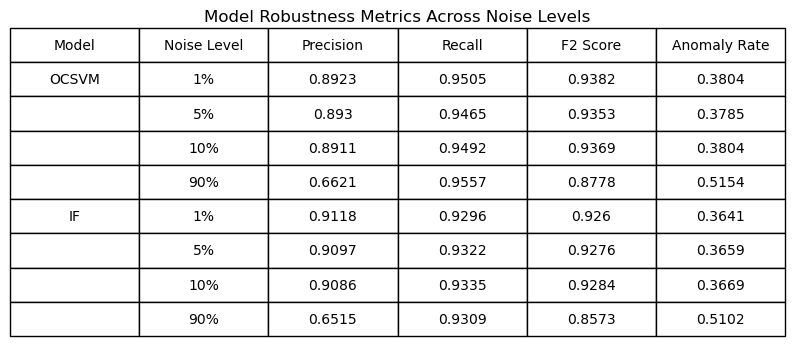

In [65]:
import matplotlib.pyplot as plt

# Use the previously created dataframe `final_table`
fig, ax = plt.subplots(figsize=(10, 4))
ax.axis('off')  # Hide axes

# Create the table
table = ax.table(
    cellText=final_table.values,
    colLabels=final_table.columns,
    cellLoc='center',
    loc='center',
    bbox=[0, 0, 1, 1]  # occupy full figure
)

# Optional styling
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 1.5)

# Title
ax.set_title("Model Robustness Metrics Across Noise Levels", pad=5)

# Save as image
plt.savefig("robustness_grouped_table.png", bbox_inches='tight')
plt.show()

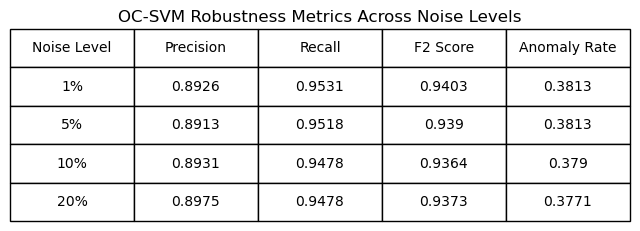

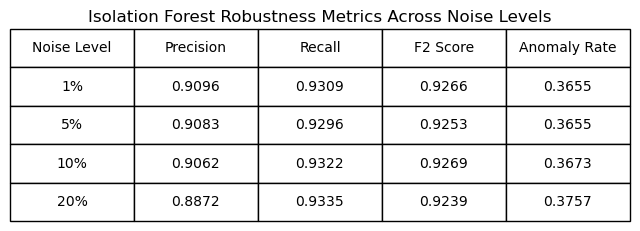

In [69]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score, fbeta_score

# ---- Parameters ----
noise_levels = [0.01, 0.05, 0.10, 0.20]  # 1%, 5%, 10%, 90%
models = [('OCSVM', ocsvm), ('IF', isoforest)]  # Your trained models
rows = []

# ---- Compute metrics ----
for model_name, model in models:
    for noise in noise_levels:
        # Add Gaussian noise to the test set
        X_test_noisy = X_test_scaled + np.random.normal(0, noise, X_test_scaled.shape)
        
        # Make predictions
        pred = (model.predict(X_test_noisy) == -1).astype(int)
        
        # Save metrics
        rows.append({
            'Model': model_name,
            'Noise Level': f"{int(noise*100)}%",
            'Precision': round(precision_score(y_test, pred), 4),
            'Recall': round(recall_score(y_test, pred), 4),
            'F2 Score': round(fbeta_score(y_test, pred, beta=2), 4),
            'Anomaly Rate': round(pred.mean(), 4)
        })

# ---- Create DataFrame ----
final_table = pd.DataFrame(rows)

# ---- Separate tables for OC-SVM and IF ----
ocsvm_df = final_table[final_table['Model'] == 'OCSVM'].drop(columns='Model').reset_index(drop=True)
if_df = final_table[final_table['Model'] == 'IF'].drop(columns='Model').reset_index(drop=True)

# ---- Function to plot and save table ----
def plot_table(df, title, filename):
    fig, ax = plt.subplots(figsize=(8, 2.5))
    ax.axis('off')
    ax.set_title(title, pad=5)
    table = ax.table(
        cellText=df.values,
        colLabels=df.columns,
        cellLoc='center',
        bbox=[0, 0, 1, 1]
    )
    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.scale(1, 1.5)
    
    # Save the figure
    plt.savefig(filename, bbox_inches='tight', dpi=300)
    plt.show()

# ---- Plot and save the tables ----
plot_table(ocsvm_df, "OC-SVM Robustness Metrics Across Noise Levels", "OCSVM_noise_metrics.png")
plot_table(if_df, "Isolation Forest Robustness Metrics Across Noise Levels", "IF_noise_metrics.png")

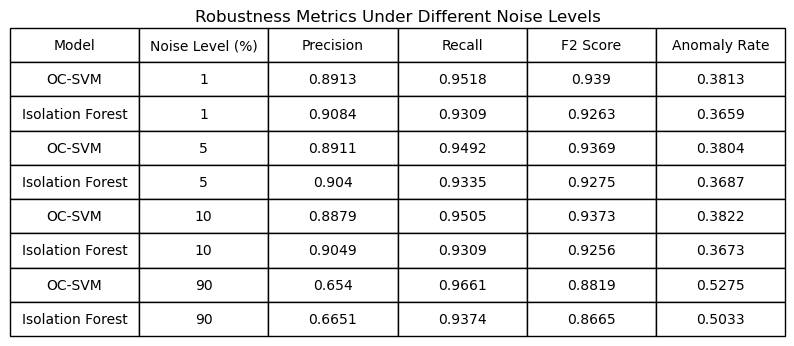

In [63]:
import matplotlib.pyplot as plt

# Reset index so table can display both row labels
table_df = noise_df.reset_index()

fig, ax = plt.subplots(figsize=(10, 4))
ax.axis('off')

table = ax.table(
    cellText=table_df.values,
    colLabels=table_df.columns,
    cellLoc='center',
    bbox=[0, 0, 1, 1]
)

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 1.5)

ax.set_title("Robustness Metrics Under Different Noise Levels", pad=5)

plt.savefig("noise_robustness_table.png", bbox_inches='tight')
plt.show()

In [20]:
import shap
shap.initjs()

In [22]:
explainer_ocsvm = shap.KernelExplainer(
    lambda x: ocsvm.decision_function(x),
    X_train_scaled
)

Using 5524 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.
100%|██████████████████████████████████████████████████████████████████████████████| 1000/1000 [17:07<00:00,  1.03s/it]


In [30]:
shap_values_ocsvm = explainer_ocsvm.shap_values(X_test_scaled)

100%|██████████████████████████████████████████████████████████████████████████████| 2148/2148 [36:44<00:00,  1.03s/it]


In [28]:
explainer_isoforest = shap.KernelExplainer(
    lambda x: isoforest.decision_function(x),
    X_train_scaled
)

shap_values_isoforest = explainer_isoforest.shap_values(X_test_scaled)

Using 5524 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.
100%|██████████████████████████████████████████████████████████████████████████████| 2148/2148 [07:09<00:00,  5.00it/s]


In [37]:
shap_values_isoforest = explainer_isoforest.shap_values(X_test_scaled)

100%|██████████████████████████████████████████████████████████████████████████████| 2148/2148 [06:51<00:00,  5.22it/s]


In [29]:
feature_names = [
    'isoforest_shap_temperature',
    'isoforest_shap_pressure',
    'isoforest_shap_vibration',
    'isoforest_shap_humidity'
]

shap_df = pd.DataFrame(
    shap_values_isoforest,
    columns=feature_names,
    index=X_test_copy.index
)

# Merge SHAP values into test dataframe
X_test_copy = pd.concat([X_test_copy, shap_df], axis=1)

In [31]:
feature_names_ocsvm = [
    'ocsvm_shap_temperature',
    'ocsvm_shap_pressure',
    'ocsvm_shap_vibration',
    'ocsvm_shap_humidity'
]

shap_df_ocsvm = pd.DataFrame(
    shap_values_ocsvm,
    columns=feature_names_ocsvm,
    index=X_test_copy.index
)

# Merge SHAP values into test dataframe
X_test_copy = pd.concat([X_test_copy, shap_df_ocsvm], axis=1)

In [32]:
X_test_copy.to_csv("X_test_copy.csv", index=False)

In [33]:
X_test_copy.to_csv("Fault_detection_project_results.csv", index=False)


Equipment: Pump


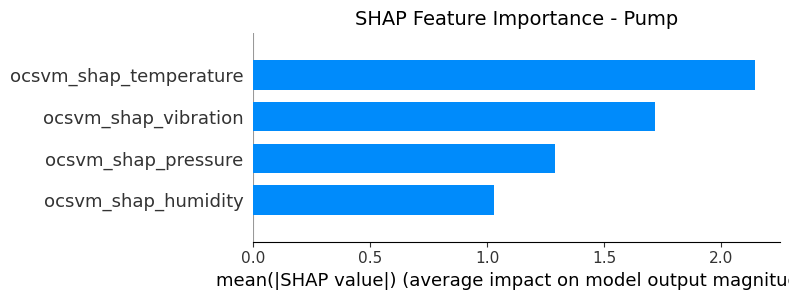


Equipment: Compressor


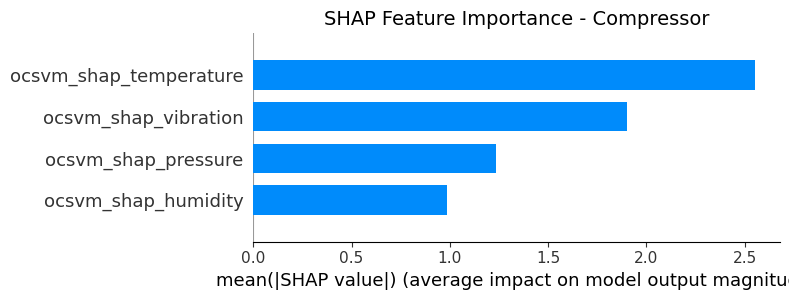


Equipment: Turbine


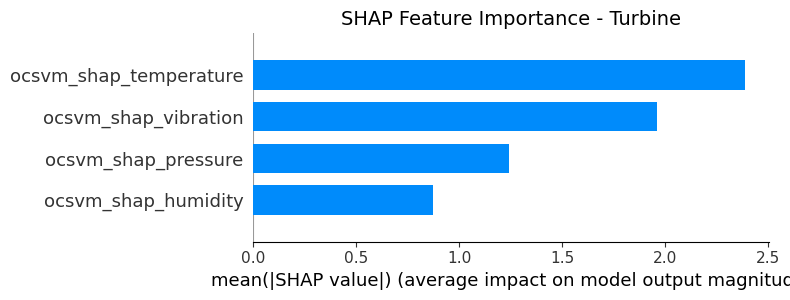

In [42]:
import os

# Create folder to store plots
os.makedirs("shap_plots_equipment", exist_ok=True)

for eq in X_test_copy['equipment'].unique():

    print(f"\nEquipment: {eq}")

    idx = X_test_copy[X_test_copy['equipment'] == eq].index

    plt.figure(figsize=(10,6))

    shap.summary_plot(
        shap_values_ocsvm[idx],
        X_test_scaled[idx],
        feature_names=feature_names_ocsvm,
        plot_type="bar",
        show=False
    )

    plt.title(f"SHAP Feature Importance - {eq}", fontsize=14)
    plt.tight_layout()

    # Save plot ⭐
    plt.savefig(f"shap_plots_equipment/shap_bar_{eq}.png", dpi=300)

    plt.show()


Equipment: Pump


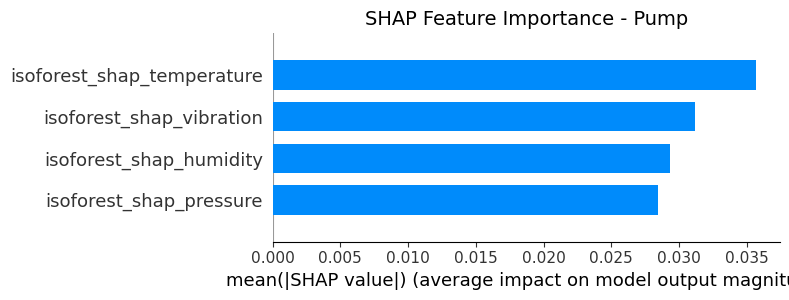


Equipment: Compressor


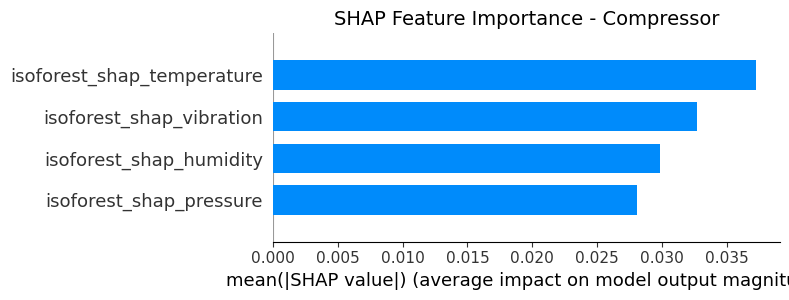


Equipment: Turbine


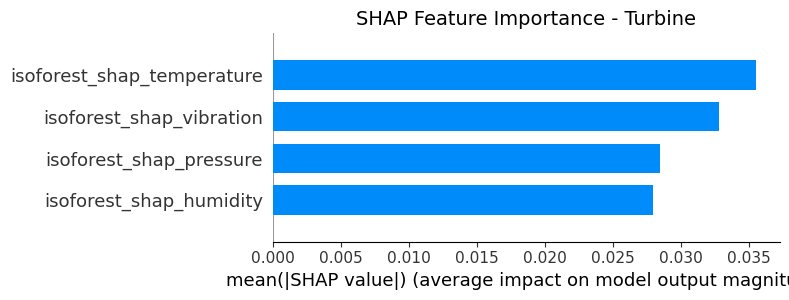

In [43]:
import os

# Create folder to store plots
os.makedirs("shap_plots_equipment_isoforest", exist_ok=True)

for eq in X_test_copy['equipment'].unique():

    print(f"\nEquipment: {eq}")

    idx = X_test_copy[X_test_copy['equipment'] == eq].index

    plt.figure(figsize=(10,6))

    shap.summary_plot(
        shap_values_isoforest[idx],
        X_test_scaled[idx],
        feature_names=feature_names,
        plot_type="bar",
        show=False   # VERY IMPORTANT ⭐
    )

    plt.title(f"SHAP Feature Importance - {eq}", fontsize=14)
    plt.tight_layout()

    # Save plot ⭐
    plt.savefig(f"shap_plots_equipment_isoforest/shap_bar_{eq}.png", dpi=300)

    plt.show()


Optimal nu: 0.0140
FP: 29
FN: 57
Total Error: 86


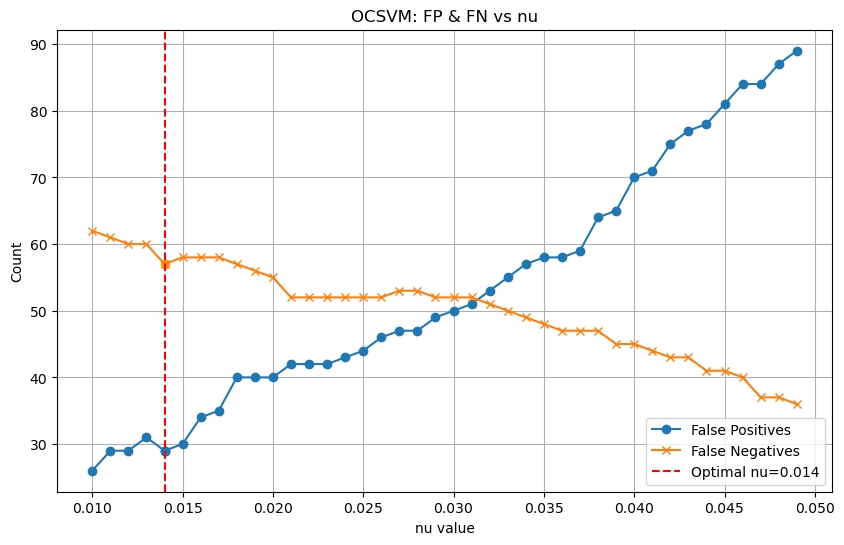

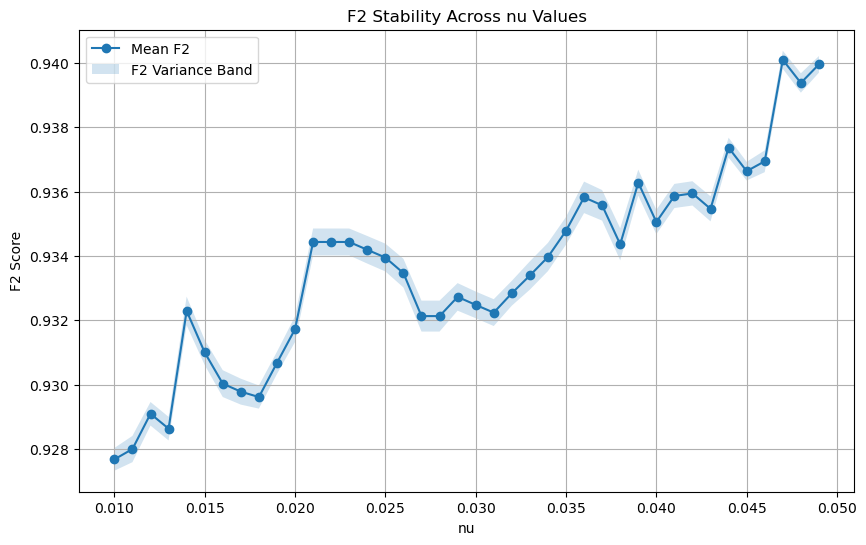


Equipment Level F2 Statistics:

Pump
Mean F2: 0.9131
Variance F2: 0.000011

Compressor
Mean F2: 0.9604
Variance F2: 0.000007

Turbine
Mean F2: 0.9273
Variance F2: 0.000025


In [49]:
from sklearn.svm import OneClassSVM
from sklearn.metrics import confusion_matrix, fbeta_score
import numpy as np
import matplotlib.pyplot as plt

# Parameter grid
nu_values = np.arange(0.01, 0.05, 0.001)

FP_list = []
FN_list = []

equipment_list = X_test_copy['equipment'].unique()

# Store F2 per equipment
f2_equipment_results = {eq: [] for eq in equipment_list}

# Store mean + variance F2
f2_mean_list = []
f2_var_list = []

y_test = X_test_copy['faulty'].values

# -----------------------------
# Hyperparameter Search Loop
# -----------------------------
for nu in nu_values:

    ocsvm = OneClassSVM(
        kernel='rbf',
        gamma='auto',
        nu=nu
    )

    ocsvm.fit(X_train_scaled)

    y_pred = ocsvm.predict(X_test_scaled)
    y_pred_binary = np.where(y_pred == -1, 1, 0)

    # Overall confusion matrix
    tn, fp, fn, tp = confusion_matrix(
        y_test,
        y_pred_binary
    ).ravel()

    FP_list.append(fp)
    FN_list.append(fn)

    # -----------------------------
    # Equipment Level F2 Analysis ⭐
    # -----------------------------
    f2_scores_equipment = []

    for eq in equipment_list:

        idx = X_test_copy[X_test_copy['equipment'] == eq].index

        if len(idx) > 0:

            f2 = fbeta_score(
                y_test[idx],
                y_pred_binary[idx],
                beta=2
            )

            f2_equipment_results[eq].append(f2)
            f2_scores_equipment.append(f2)

    # Mean + variance across equipment
    f2_mean_list.append(np.mean(f2_scores_equipment))
    f2_var_list.append(np.var(f2_scores_equipment))

# -----------------------------
# Optimal Nu Selection
# -----------------------------
total_error = np.array(FP_list) + np.array(FN_list)

best_idx = np.argmin(total_error)
best_nu = nu_values[best_idx]

print(f"\nOptimal nu: {best_nu:.4f}")
print(f"FP: {FP_list[best_idx]}")
print(f"FN: {FN_list[best_idx]}")
print(f"Total Error: {total_error[best_idx]}")

# -----------------------------
# Plot FP / FN Curve
# -----------------------------
plt.figure(figsize=(10,6))

plt.plot(nu_values, FP_list, label="False Positives", marker='o')
plt.plot(nu_values, FN_list, label="False Negatives", marker='x')

plt.axvline(
    best_nu,
    color='red',
    linestyle='--',
    label=f'Optimal nu={best_nu:.3f}'
)

plt.scatter(best_nu, FP_list[best_idx], color='blue')
plt.scatter(best_nu, FN_list[best_idx], color='orange')

plt.xlabel("nu value")
plt.ylabel("Count")
plt.title("OCSVM: FP & FN vs nu")
plt.legend()
plt.grid()
plt.show()

# -----------------------------
# F2 Stability Plot
# -----------------------------
plt.figure(figsize=(10,6))

plt.plot(nu_values, f2_mean_list,
         label="Mean F2", marker='o')

plt.fill_between(
    nu_values,
    np.array(f2_mean_list) - np.array(f2_var_list),
    np.array(f2_mean_list) + np.array(f2_var_list),
    alpha=0.2,
    label="F2 Variance Band"
)

plt.xlabel("nu")
plt.ylabel("F2 Score")
plt.title("F2 Stability Across nu Values")
plt.legend()
plt.grid()
plt.savefig('F2_stability_ocsvm')
plt.show()

# -----------------------------
# Equipment Level Statistics
# -----------------------------
print("\nEquipment Level F2 Statistics:")

for eq in equipment_list:

    arr = np.array(f2_equipment_results[eq])

    print(f"\n{eq}")
    print(f"Mean F2: {np.mean(arr):.4f}")
    print(f"Variance F2: {np.var(arr):.6f}")


Optimal contamination: 0.0320
FP: 48
FN: 66
Total error: 114


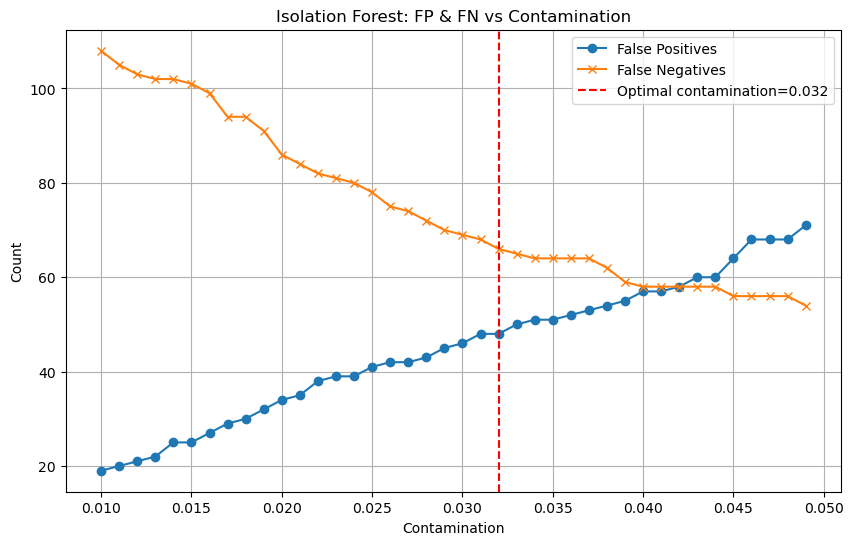

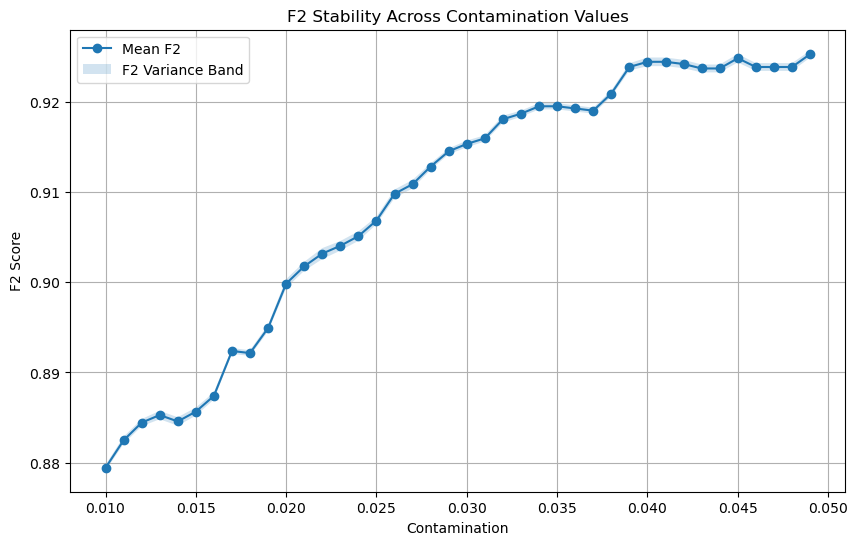


Equipment Level F2 Statistics:

Pump
Mean F2: 0.8863
Variance F2: 0.000190

Compressor
Mean F2: 0.9354
Variance F2: 0.000210

Turbine
Mean F2: 0.9059
Variance F2: 0.000280


In [50]:
from sklearn.ensemble import IsolationForest
from sklearn.metrics import confusion_matrix, fbeta_score
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Parameter grid
contamination_values = np.arange(0.01, 0.05, 0.001)

FP_list = []
FN_list = []

# Store F2 results per equipment
equipment_list = X_test_copy['equipment'].unique()
f2_equipment_results = {eq: [] for eq in equipment_list}

# Store mean + variance F2 per parameter
f2_mean_list = []
f2_var_list = []

y_test = X_test_copy['faulty'].values

for cont in contamination_values:

    iso = IsolationForest(
        n_estimators=100,
        contamination=cont,
        random_state=42
    )

    iso.fit(X_train_scaled)

    y_pred = iso.predict(X_test_scaled)
    y_pred_binary = np.where(y_pred == -1, 1, 0)

    # Overall FP/FN
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_binary).ravel()

    FP_list.append(fp)
    FN_list.append(fn)

    # Equipment level F2 analysis ⭐⭐⭐⭐⭐
    f2_scores_equipment = []

    for eq in equipment_list:

        idx = X_test_copy[X_test_copy['equipment'] == eq].index

        if len(idx) > 0:

            f2 = fbeta_score(
                y_test[idx],
                y_pred_binary[idx],
                beta=2
            )

            f2_equipment_results[eq].append(f2)
            f2_scores_equipment.append(f2)

    # Mean + variance across equipments
    f2_mean_list.append(np.mean(f2_scores_equipment))
    f2_var_list.append(np.var(f2_scores_equipment))

# ==========================
# Best parameter selection
# ==========================
total_error = np.array(FP_list) + np.array(FN_list)

best_idx = np.argmin(total_error)
best_cont = contamination_values[best_idx]

print(f"\nOptimal contamination: {best_cont:.4f}")
print(f"FP: {FP_list[best_idx]}")
print(f"FN: {FN_list[best_idx]}")
print(f"Total error: {total_error[best_idx]}")

# ==========================
# Plot FP FN Curve
# ==========================
plt.figure(figsize=(10,6))

plt.plot(contamination_values, FP_list, label="False Positives", marker='o')
plt.plot(contamination_values, FN_list, label="False Negatives", marker='x')

plt.axvline(best_cont, color='red', linestyle='--',
            label=f'Optimal contamination={best_cont:.3f}')

plt.xlabel("Contamination")
plt.ylabel("Count")
plt.title("Isolation Forest: FP & FN vs Contamination")
plt.legend()
plt.grid()
plt.show()

# ==========================
# Plot Mean + Variance F2 Across Parameters
# ==========================
plt.figure(figsize=(10,6))

plt.plot(contamination_values, f2_mean_list,
         label="Mean F2", marker='o')

plt.fill_between(
    contamination_values,
    np.array(f2_mean_list) - np.array(f2_var_list),
    np.array(f2_mean_list) + np.array(f2_var_list),
    alpha=0.2,
    label="F2 Variance Band"
)

plt.xlabel("Contamination")
plt.ylabel("F2 Score")
plt.title("F2 Stability Across Contamination Values")
plt.legend()
plt.grid()
plt.savefig('F2_stability_scores_IF')
plt.show()

# ==========================
# Print Equipment Level Statistics
# ==========================
print("\nEquipment Level F2 Statistics:")

for eq in equipment_list:

    arr = np.array(f2_equipment_results[eq])

    print(f"\n{eq}")
    print(f"Mean F2: {np.mean(arr):.4f}")
    print(f"Variance F2: {np.var(arr):.6f}")